In [6]:
import torch
import torch_geometric.transforms as T
from torch_geometric.nn import GATv2Conv
from torch_geometric.data import DataLoader
from torch_geometric.datasets import Planetoid

device = "cuda" if torch.cuda.is_available() else "cpu"
dataset_name = "Cora"

In [7]:
transform = T.Compose([T.NormalizeFeatures(),T.ToUndirected(),T.AddSelfLoops()])
dataset = Planetoid(root=f"/{dataset_name}",name =dataset_name,transform=transform)
print(dataset)
loader  = DataLoader(dataset,batch_size=32,shuffle=True)

Processing...
C:\Users\ssary\AppData\Roaming\Python\Python314\site-packages\torch_geometric\io\planetoid.py:107: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  out = pickle.load(f, encoding='latin1')
C:\Users\ssary\AppData\Roaming\Python\Python314\site-packages\torch_geometric\io\planetoid.py:107: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  out = pickle.load(f, encoding='latin1')
C:\Users\ssary\AppData\Roaming\Python\Python314\site-packages\torch_geometric\io\planetoid.py:107: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  out = pickle.load(f, encoding='latin1')
C:\Users\ss

Cora()


Done!
C:\Users\ssary\AppData\Local\Temp\ipykernel_17072\3523524016.py:4: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  loader  = DataLoader(dataset,batch_size=32,shuffle=True)


In [8]:
class GAT(torch.nn.Module):
    def __init__(self,layer_sizes):
        super().__init__()
        self.n = len(layer_sizes)-1
        self.layers = torch.nn.ModuleList([GATv2Conv(layer_sizes[i],layer_sizes[i+1]) for i in range(self.n)])
        self.leakyrelu = torch.nn.LeakyReLU(negative_slope=0.01)
        self.dropout = torch.nn.Dropout(p=0.8)
    
    def forward(self,dataset):
        x,edge_index = dataset.x,dataset.edge_index
        for layer in self.layers:
            x = layer(x,edge_index)
            x = self.leakyrelu(x)
            x = self.dropout(x)
        return torch.nn.functional.log_softmax(x)


In [9]:
model = GAT([dataset.num_node_features,64,dataset.num_classes]).to(device)
print(model)

GAT(
  (layers): ModuleList(
    (0): GATv2Conv(1433, 64, heads=1)
    (1): GATv2Conv(64, 7, heads=1)
  )
  (leakyrelu): LeakyReLU(negative_slope=0.01)
  (dropout): Dropout(p=0.8, inplace=False)
)


In [10]:
epochs = 2000
patience = 200
optimizer = torch.optim.Adam(model.parameters(),lr=0.001,weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()
data = dataset[0].to(device)
counter = 0
best_val_loss = float('inf')
train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    total_train_loss = 0
    for batch in loader:
        optimizer.zero_grad()
        out = model(batch.to(device))
        loss = criterion(out[batch.train_mask],batch.y[batch.train_mask])
        loss.backward()
        total_train_loss += loss.item()
        optimizer.step()
    train_losses.append(total_train_loss)

    model.eval()
    out = model(data)
    val_loss = criterion(out[data.val_mask],data.y[data.val_mask])
    val_losses.append(val_loss.item())
    if(best_val_loss>val_loss):
        best_val_loss = val_loss
        torch.save(model.state_dict(),"best_gat.pickle")
        counter = 0
    else :
        counter += 1
    if epoch == 0 or epoch%20==19:
        print(f"Epoch {epoch+1} of {epochs}, train loss = {total_train_loss}, val loss = {val_loss.item()}")
    if counter>=patience:
        break

with torch.no_grad():
    model.load_state_dict(torch.load("best_gat.pickle",weights_only=True))
    model.eval()
    out = model(data)
    y_pred = torch.argmax(out,dim=1)
    loss = criterion(out[data.test_mask],data.y[data.test_mask])
    accuracy = (y_pred[data.test_mask]==data.y[data.test_mask]).sum().item()/data.test_mask.sum().item()
    print(f"Test metrics: Loss: {loss.item()}, Accuracy: {accuracy}")


C:\Users\ssary\AppData\Local\Temp\ipykernel_17072\2555204942.py:15: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return torch.nn.functional.log_softmax(x)


Epoch 1 of 2000, train loss = 1.9429068565368652, val loss = 1.9456472396850586
Epoch 20 of 2000, train loss = 1.9437437057495117, val loss = 1.9412102699279785
Epoch 40 of 2000, train loss = 1.9295507669448853, val loss = 1.9381824731826782
Epoch 60 of 2000, train loss = 1.9114351272583008, val loss = 1.9305552244186401
Epoch 80 of 2000, train loss = 1.9074981212615967, val loss = 1.919270396232605
Epoch 100 of 2000, train loss = 1.8764585256576538, val loss = 1.9096760749816895
Epoch 120 of 2000, train loss = 1.8899102210998535, val loss = 1.8981314897537231
Epoch 140 of 2000, train loss = 1.8448939323425293, val loss = 1.8875364065170288
Epoch 160 of 2000, train loss = 1.844262719154358, val loss = 1.8762168884277344
Epoch 180 of 2000, train loss = 1.837376594543457, val loss = 1.8641451597213745
Epoch 200 of 2000, train loss = 1.8243917226791382, val loss = 1.8556904792785645
Epoch 220 of 2000, train loss = 1.8405896425247192, val loss = 1.8433715105056763
Epoch 240 of 2000, train 

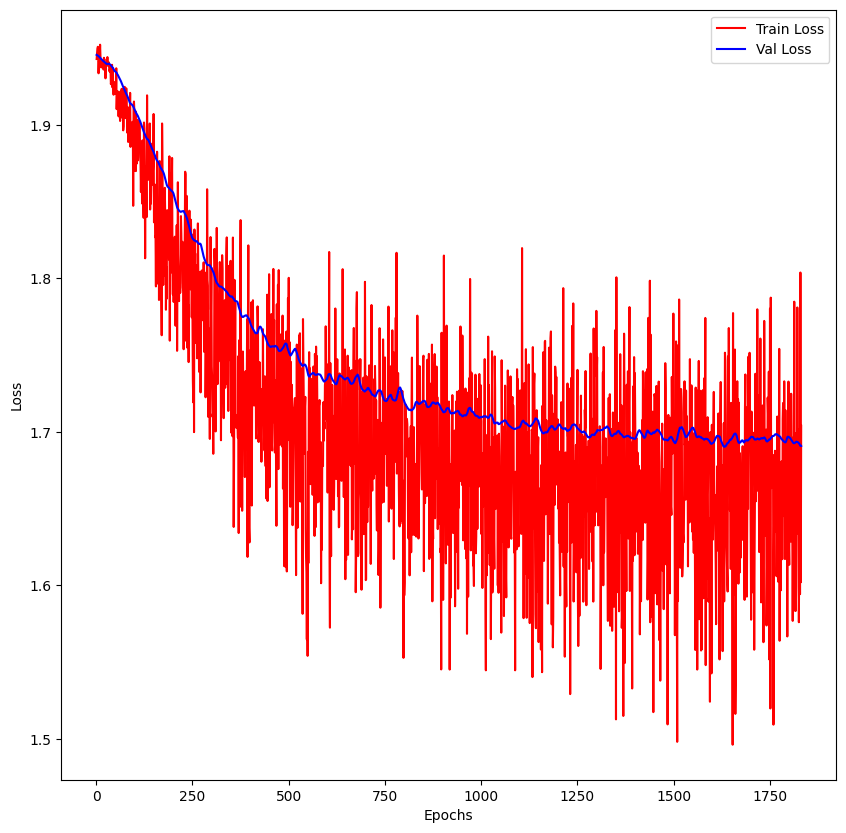

In [11]:
import matplotlib.pyplot as plt

total = len(train_losses)
x_vals = range(1,total+1)
plt.figure(figsize = (10,10))
plt.plot(x_vals,train_losses,color="red",label="Train Loss")
plt.plot(x_vals,val_losses,color="blue",label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [12]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

@torch.no_grad()
def get_labels():
    model.eval()
    out = model(data)
    pred = torch.argmax(out,dim=1)
    
    y_pred = pred[data.test_mask].cpu().numpy()
    y_true = data.y[data.test_mask].cpu().numpy()
    return y_true,y_pred

C:\Users\ssary\AppData\Local\Temp\ipykernel_17072\2555204942.py:15: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return torch.nn.functional.log_softmax(x)


<Axes: >

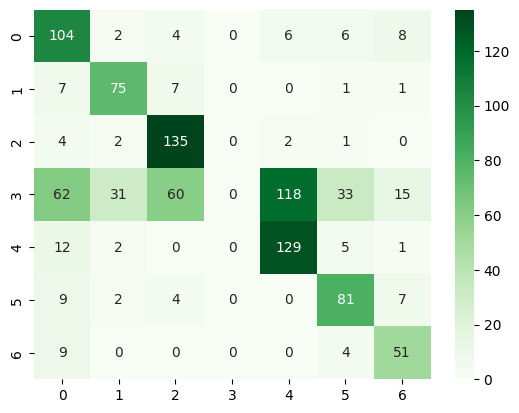

In [13]:
y_true,y_pred = get_labels()
cm = confusion_matrix(y_true=y_true,y_pred=y_pred)
sns.heatmap(cm,annot=True,fmt='d',cmap="Greens",xticklabels=range(dataset.num_classes),yticklabels=range(dataset.num_classes))